## API setup

In [3]:
!pip install nas-bench-201



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\aless\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from nas_201_api import NASBench201API as API
#loading api 
api = API(
    r'datasets\NAS-Bench-201-v1_1-096897.pth',
    verbose=False
)

print(len(api))

AssertionError: invalid path : datasets\NAS-Bench-201-v1_1-096897.pth

In [ ]:
import torch
import numpy as np
import random

seed = 42

# Python random
random.seed(seed)

# NumPy
np.random.seed(seed)

# PyTorch CPU
torch.manual_seed(seed)

# PyTorch GPU (se usi CUDA)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# per riproducibilità più forte (può rallentare)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## API inspection 

un elemento del dataset:
- DAG dell'architettura in cui ogni nodo è una cella di operazioni (conv, max pooling..)
- risultati su vari datasets e su regime brene e lungo di training 

In [ ]:
api.show(1)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> 012 epochs >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|
datasets : ['cifar10-valid', 'cifar10', 'cifar100', 'ImageNet16-120'], extra-info : None
cifar10-valid  FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10-valid  train : [loss = 0.382, top1 = 86.97%], valid : [loss = 0.514, top1 = 82.83%]
cifar10        FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10        train : [loss = 0.243, top1 = 91.69%], test  : [loss = 0.362, top1 = 88.22%]
cifar100       FLOP=113.96 M, Params=0.808 MB, latency=15.36 ms.
cifar100       train : [loss = 1.271, top1 = 63.76%], valid : [loss = 1.495, top1 = 57.80%], test : [loss = 1.478, top1 = 58.26%]
ImageNet16-120 FLOP= 28.50 M, Params=0.810 MB, latency=13.77 ms.
ImageNet16-120 train : [loss = 2.548, top1 = 35.41%], valid : [loss = 2.580, top1 = 35.43%], test : [loss = 2.611, top1 = 33.80%]
>>>>>>>>>>>>>>>>>>

La stringa **|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|**
- node-0: the input tensor
- node-1: conv-3x3( node-0 )
- node-2: conv-3x3( node-0 ) + avg-pool-3x3( node-1 )
- node-3: skip-connect( node-0 ) + conv-3x3( node-1 ) + skip-connect( node-2 )

per vedere risultati su un datasets e una specifica architettura 

In [ ]:
# show the mean loss and accuracy of an architecture
info = api.query_meta_info_by_index(1)  # This is an instance of `ArchResults`
res_metrics = info.get_metrics('cifar10', 'train') # This is a dict with metric names as keys

# get the detailed information
results = api.query_by_index(1, 'cifar100') # a dict of all trials for 1st net on cifar100, where the key is the seed
print ('There are {:} trials for this architecture [{:}] on cifar100'.format(len(results), api[1]))
for seed, result in results.items():
  print ('Latency : {:}'.format(result.get_latency()))
  print ('Train Info : {:}'.format(result.get_train()))
  print ('Valid Info : {:}'.format(result.get_eval('x-valid')))
  print ('Test  Info : {:}'.format(result.get_eval('x-test')))
  # for the metric after a specific epoch
  print ('Train Info [10-th epoch] : {:}'.format(result.get_train(10)))

There are 1 trials for this architecture [|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|] on cifar100
Latency : 0.015363384176183631
Train Info : {'iepoch': 11, 'loss': 1.2711473697662354, 'accuracy': 63.756, 'cur_time': 21.69641375541687, 'all_time': 260.35696506500244}
Valid Info : {'iepoch': 11, 'loss': 1.495258326148987, 'accuracy': 57.79999996948242, 'cur_time': 0.7508397953850883, 'all_time': 9.01007754462106}
Test  Info : {'iepoch': 11, 'loss': 1.477725588607788, 'accuracy': 58.25999995727539, 'cur_time': 0.7508397953850883, 'all_time': 9.01007754462106}
Train Info [10-th epoch] : {'iepoch': 10, 'loss': 1.3365458668136596, 'accuracy': 61.568, 'cur_time': 21.69641375541687, 'all_time': 238.66055130958557}


tokenizzazione del tipo: 
asse 0 → tipo di operazione
asse 1 → nodo sorgente
asse 2 → nodo destinazione

In [ ]:
api[0]

'|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|'

In [ ]:
import numpy as np
import re

# mapping operazioni → indice tensor
OPS = {
    'nor_conv_3x3': 0,
    'nor_conv_1x1': 1,
    'skip_connect': 2,
    'avg_pool_3x3': 3
}

def arch_to_tensor(arch_str):
    """
    Converte una stringa NAS-Bench-201 in:

        A[operation, i, j]

    shape:
        [num_ops, num_nodes, num_nodes]
    """

    # separa i nodi
    nodes = arch_str.split('+')

    # numero totale nodi
    # input + nodi intermedi
    N = len(nodes) + 1

    K = len(OPS)

    # adjacency tensor
    A = np.zeros((K, N, N), dtype=np.float32)

    # parse
    for dst, node in enumerate(nodes, start=1):

        # trova edge tipo:
        # nor_conv_3x3~0
        edges = re.findall(
            r'(nor_conv_3x3|nor_conv_1x1|skip_connect|avg_pool_3x3)~(\d)',
            node
        )

        for op_name, src in edges:

            src = int(src)

            op_idx = OPS[op_name]

            A[op_idx, src, dst] = 1.0

    return A

In [ ]:
arch_to_tensor(arch_str=api[0])


array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 1., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]], dtype=float32)

In [ ]:
import numpy as np

all_tensors = []

for i in range(len(api)):

    arch_str = api[i]

    A = arch_to_tensor(arch_str)

    all_tensors.append(A)

X = np.stack(all_tensors)
X.shape

(15625, 4, 4, 4)

In [ ]:
import torch
X = torch.tensor(X)
X.shape

torch.Size([15625, 4, 4, 4])

In [ ]:
X = X.view(len(X), -1)
X.shape

torch.Size([15625, 64])

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

LATENT_DIM = 16
INPUT_DIM = 64


class VAE(nn.Module):

    def __init__(self):

        super().__init__()

        # encoder
        self.fc1 = nn.Linear(INPUT_DIM, 128)
        self.fc2 = nn.Linear(128, 64)

        self.mu = nn.Linear(64, LATENT_DIM)
        self.logvar = nn.Linear(64, LATENT_DIM)

        # decoder
        self.fc3 = nn.Linear(LATENT_DIM, 64)
        self.fc4 = nn.Linear(64, 128)
        self.fc5 = nn.Linear(128, INPUT_DIM)

    def encode(self, x):

        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))

        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))

        return torch.sigmoid(self.fc5(h))

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

In [ ]:
import torch.nn.functional as F

def vae_loss(recon, x, mu, logvar,beta=1):

    # ricostruzione
    recon_loss = F.binary_cross_entropy(
        recon,
        x,
        reduction='sum'
    )

    # KL divergence
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl * beta

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [ ]:
model = VAE()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 50

model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch in loader:

        x = batch[0]

        # forward
        recon, mu, logvar = model(x)

        loss = vae_loss(recon, x, mu, logvar,beta=1.5)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.2f}")

Epoch 1 | Loss: 277929.55
Epoch 2 | Loss: 190086.35
Epoch 3 | Loss: 189478.34
Epoch 4 | Loss: 189262.92
Epoch 5 | Loss: 189043.69
Epoch 6 | Loss: 188963.53
Epoch 7 | Loss: 188787.51
Epoch 8 | Loss: 188704.54
Epoch 9 | Loss: 188526.56
Epoch 10 | Loss: 188489.32
Epoch 11 | Loss: 188361.04
Epoch 12 | Loss: 188410.41
Epoch 13 | Loss: 188224.79
Epoch 14 | Loss: 188158.92
Epoch 15 | Loss: 188201.01
Epoch 16 | Loss: 188121.54
Epoch 17 | Loss: 188074.99
Epoch 18 | Loss: 188064.07
Epoch 19 | Loss: 188093.90
Epoch 20 | Loss: 188115.71
Epoch 21 | Loss: 187991.15
Epoch 22 | Loss: 188017.42
Epoch 23 | Loss: 188033.67
Epoch 24 | Loss: 187944.81
Epoch 25 | Loss: 187955.78
Epoch 26 | Loss: 187945.89
Epoch 27 | Loss: 187900.61
Epoch 28 | Loss: 187913.79
Epoch 29 | Loss: 187906.35
Epoch 30 | Loss: 187887.87
Epoch 31 | Loss: 187878.99
Epoch 32 | Loss: 187873.89
Epoch 33 | Loss: 187902.82
Epoch 34 | Loss: 187884.83
Epoch 35 | Loss: 187826.44
Epoch 36 | Loss: 187846.51
Epoch 37 | Loss: 187802.06
Epoch 38 |

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()

with torch.no_grad():

    mu, logvar = model.encode(X)

    z = mu   # embedding stabile
z = z.numpy()  # embedding del VAE

pca = PCA(n_components=2)
z_2d = pca.fit_transform(z)


In [ ]:
acc = np.zeros(len(api))
for i in range(len(api)):
    acc[i] = api.get_more_info(i, dataset='cifar100')['test-accuracy']

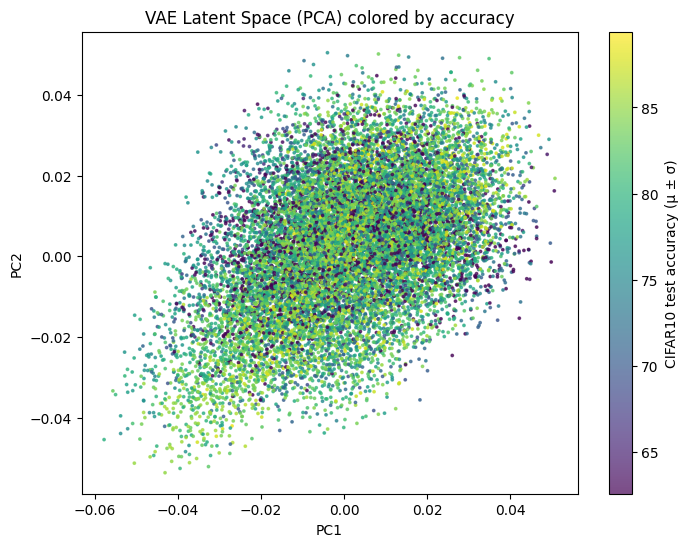

In [ ]:

# ----------------------------
# 1. ESTRAI ACCURACY
# ----------------------------
acc = np.zeros(len(api))

for i in range(len(api)):
    acc[i] = api.get_more_info(i, dataset='cifar10')['test-accuracy']

acc = np.array(acc)

# ----------------------------
# 2. STATISTICHE
# ----------------------------
mu = np.mean(acc)
std = np.std(acc)

vmin = mu - std
vmax = mu + std

# ----------------------------
# 4. PLOT
# ----------------------------
plt.figure(figsize=(8,6))

sc = plt.scatter(
    z[:, 0],
    z[:, 1],
    c=acc,
    cmap='viridis',
    s=3,
    alpha=0.7,
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(sc, label="CIFAR10 test accuracy (μ ± σ)")

plt.title("VAE Latent Space (PCA) colored by accuracy")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()